# Argentina vs Colombia - Copa America 2024

Analisis del partido utilizando event data de StatsBomb Open Data.

El objetivo es explorar el rendimiento de ambos equipos mediante datos de eventos, comenzando por tiros y xG y posteriormente incorporando pases, progresion y acciones defensivas.

In [146]:
import json

import pandas as pd
import matplotlib.pyplot as plt

from mplsoccer import Pitch

## Identificacion del partido

Primero se identifica la Copa America 2024 y posteriormente la final Argentina vs Colombia dentro de los datos de StatsBomb.

In [147]:
df_competiciones = pd.read_json(
    "../data/statsbomb/competitions.json"
)

df_copa_america = df_competiciones[
    (df_competiciones["competition_name"] == "Copa America") &
    (df_competiciones["season_name"] == "2024")
]

df_copa_america[
    [
        "competition_id",
        "season_id",
        "competition_name",
        "season_name"
    ]
]

,competition_id,season_id,competition_name,season_name
21,223,282,Copa America,2024


In [148]:
df_partidos = pd.read_json(
    "../data/statsbomb/matches_223_282.json"
)

In [149]:
def obtener_nombre_local(equipo):
    return equipo["home_team_name"]


def obtener_nombre_visitante(equipo):
    return equipo["away_team_name"]


df_partidos["home_team_name"] = df_partidos["home_team"].apply(
    obtener_nombre_local
)

df_partidos["away_team_name"] = df_partidos["away_team"].apply(
    obtener_nombre_visitante
)

In [150]:
df_final = df_partidos[
    (
        (df_partidos["home_team_name"] == "Argentina") &
        (df_partidos["away_team_name"] == "Colombia")
    )
    |
    (
        (df_partidos["home_team_name"] == "Colombia") &
        (df_partidos["away_team_name"] == "Argentina")
    )
]

df_final[
    [
        "match_id",
        "match_date",
        "home_team_name",
        "away_team_name",
        "home_score",
        "away_score"
    ]
]

,match_id,match_date,home_team_name,away_team_name,home_score,away_score
19,3943077,2024-07-15,Argentina,Colombia,1,0


In [151]:
match_id = df_final["match_id"].iloc[0]

match_id

np.int64(3943077)

## Eventos del partido

StatsBomb registra cada accion del partido como un evento. El dataset incluye pases, tiros, conducciones, presiones, recuperaciones, duelos y otras acciones.

Los eventos se normalizan para facilitar su analisis con Pandas.

In [152]:
with open(
    "../data/statsbomb/events_3943077.json",
    "r",
    encoding="utf-8"
) as archivo:
    datos_eventos = json.load(archivo)

In [153]:
df_eventos = pd.json_normalize(datos_eventos)

In [154]:
df_eventos.shape

(4146, 119)

In [155]:
df_eventos[
    [
        "minute",
        "second",
        "type.name",
        "team.name",
        "player.name",
        "location"
    ]
].head(10)

,minute,second,type.name,team.name,player.name,location
0,0,0,Starting XI,Argentina,NaN,NaN
1,0,0,Starting XI,Colombia,NaN,NaN
2,0,0,Half Start,Argentina,NaN,NaN
3,0,0,Half Start,Colombia,NaN,NaN
4,0,0,Pass,Argentina,Lionel Andrés Messi Cuccittini,"[61.0, 40.1]"
5,0,1,Ball Receipt*,Argentina,Enzo Fernandez,"[51.0, 40.0]"
6,0,1,Carry,Argentina,Enzo Fernandez,"[51.0, 40.0]"
7,0,2,Pass,Argentina,Enzo Fernandez,"[48.6, 41.0]"
8,0,2,Ball Receipt*,Argentina,Rodrigo Javier De Paul,"[45.6, 54.5]"
9,0,2,Carry,Argentina,Rodrigo Javier De Paul,"[45.6, 54.5]"


In [156]:
df_eventos["type.name"].value_counts()

type.name
Pass                 1197
Ball Receipt*        1114
Carry                 953
Pressure              313
Ball Recovery          93
Duel                   85
Block                  44
Goal Keeper            41
Dribble                39
Foul Committed         31
Shot                   30
Foul Won               30
Clearance              27
Dispossessed           25
Dribbled Past          23
Interception           21
Miscontrol             17
Substitution           12
Half Start              8
Half End                8
Referee Ball-Drop       8
Injury Stoppage         7
50/50                   6
Tactical Shift          4
Shield                  4
Starting XI             2
Offside                 1
Player Off              1
Player On               1
Bad Behaviour           1
Name: count, dtype: int64

## Tiros y xG

Se analizan todos los eventos de tipo `Shot`.

El xG representa la probabilidad estimada de que un remate termine en gol dadas las caracteristicas de la ocasion.

In [157]:
df_tiros = df_eventos[
    df_eventos["type.name"] == "Shot"
]

In [158]:
df_tiros_limpio = df_tiros[
    [
        "period",
        "minute",
        "second",
        "team.name",
        "player.name",
        "location",
        "shot.statsbomb_xg",
        "shot.outcome.name",
        "shot.body_part.name",
        "shot.type.name"
    ]
].copy()

In [159]:
df_tiros_limpio["x"] = df_tiros_limpio["location"].apply(
    lambda ubicacion: ubicacion[0]
)

df_tiros_limpio["y"] = df_tiros_limpio["location"].apply(
    lambda ubicacion: ubicacion[1]
)

### Produccion ofensiva por equipo

Se compara el volumen de remates, el xG acumulado y la calidad promedio de las ocasiones.

In [160]:
resumen_tiros = df_tiros_limpio.groupby("team.name").agg(
    tiros=("shot.statsbomb_xg", "count"),
    xg=("shot.statsbomb_xg", "sum")
)

resumen_tiros["xg_por_tiro"] = (
    resumen_tiros["xg"] / resumen_tiros["tiros"]
)

resumen_tiros = resumen_tiros.round(3)

resumen_tiros

,tiros,xg,xg_por_tiro
team.name,,,
Argentina,11,1.083,0.098
Colombia,19,0.972,0.051


### Produccion de tiros por jugador

Se analiza cuantos tiros realizo cada jugador, cuanto xG acumulo y la calidad promedio de sus remates.

In [161]:
resumen_jugadores = df_tiros_limpio.groupby(
    ["team.name", "player.name"]
).agg(
    tiros=("shot.statsbomb_xg", "count"),
    xg=("shot.statsbomb_xg", "sum")
)

resumen_jugadores["xg_por_tiro"] = (
    resumen_jugadores["xg"] / resumen_jugadores["tiros"]
)

resumen_jugadores = resumen_jugadores.sort_values(
    by="xg",
    ascending=False
)

resumen_jugadores = resumen_jugadores.round(3)
resumen_jugadores = resumen_jugadores.reset_index()

resumen_jugadores

,team.name,player.name,tiros,xg,xg_por_tiro
0,Argentina,Nicolás Iván González,2,0.448,0.224
1,Colombia,Carlos Eccehomo Cuesta Figueroa,3,0.320,0.107
2,Colombia,Jhon Andrés Córdoba Copete,3,0.211,0.070
3,Argentina,Lautaro Javier Martínez,1,0.199,0.199
4,Argentina,Lionel Andrés Messi Cuccittini,1,0.151,0.151
5,Colombia,Davinson Sánchez Mina,1,0.126,0.126
6,Argentina,Ángel Fabián Di María Hernández,2,0.094,0.047
7,Colombia,Jhon Adolfo Arias Andrade,3,0.084,0.028
8,Argentina,Nicolás Alejandro Tagliafico,2,0.074,0.037
9,Argentina,Julián Álvarez,1,0.072,0.072


### Resultado de los remates

In [162]:
resultados_tiros = df_tiros_limpio.groupby(
    "team.name"
)["shot.outcome.name"].value_counts()

resultados_tiros

team.name  shot.outcome.name
Argentina  Saved                4
           Off T                3
           Blocked              2
           Goal                 1
           Wayward              1
Colombia   Blocked              7
           Off T                5
           Saved                4
           Wayward              2
           Post                 1
Name: count, dtype: int64

### Ocasiones de mayor xG

In [163]:
tiros_mayor_xg = df_tiros_limpio.sort_values(
    by="shot.statsbomb_xg",
    ascending=False
)

tiros_mayor_xg[
    [
        "minute",
        "second",
        "team.name",
        "player.name",
        "shot.statsbomb_xg",
        "shot.outcome.name",
        "location"
    ]
].head(10)

,minute,second,team.name,player.name,shot.statsbomb_xg,shot.outcome.name,location
3069,92,7,Argentina,Nicolás Iván González,0.262910,Off T,"[111.1, 42.0]"
3893,111,13,Argentina,Lautaro Javier Martínez,0.198811,Goal,"[105.5, 52.1]"
3321,94,8,Argentina,Nicolás Iván González,0.185260,Saved,"[110.1, 35.3]"
476,12,7,Colombia,Carlos Eccehomo Cuesta Figueroa,0.156862,Saved,"[113.4, 38.7]"
834,19,43,Argentina,Lionel Andrés Messi Cuccittini,0.151331,Blocked,"[106.2, 36.8]"
2127,53,42,Colombia,Davinson Sánchez Mina,0.125767,Off T,"[114.8, 44.1]"
4134,121,46,Colombia,Carlos Eccehomo Cuesta Figueroa,0.106778,Wayward,"[113.8, 36.7]"
1339,33,15,Colombia,Jhon Andrés Córdoba Copete,0.085104,Blocked,"[112.5, 42.5]"
243,6,12,Colombia,Jhon Andrés Córdoba Copete,0.075898,Post,"[105.5, 47.3]"
36,0,36,Argentina,Julián Álvarez,0.072140,Off T,"[105.6, 44.0]"


## Visualizacion de tiros

Todos los remates se muestran orientados hacia el mismo arco para facilitar la comparacion espacial entre Argentina y Colombia.

El tamaño de cada marcador representa el xG de la ocasion.

In [164]:
tiros_argentina = df_tiros_limpio[
    df_tiros_limpio["team.name"] == "Argentina"
].copy()

tiros_colombia = df_tiros_limpio[
    df_tiros_limpio["team.name"] == "Colombia"
].copy()

df_goles = df_tiros_limpio[
    df_tiros_limpio["shot.outcome.name"] == "Goal"
].copy()

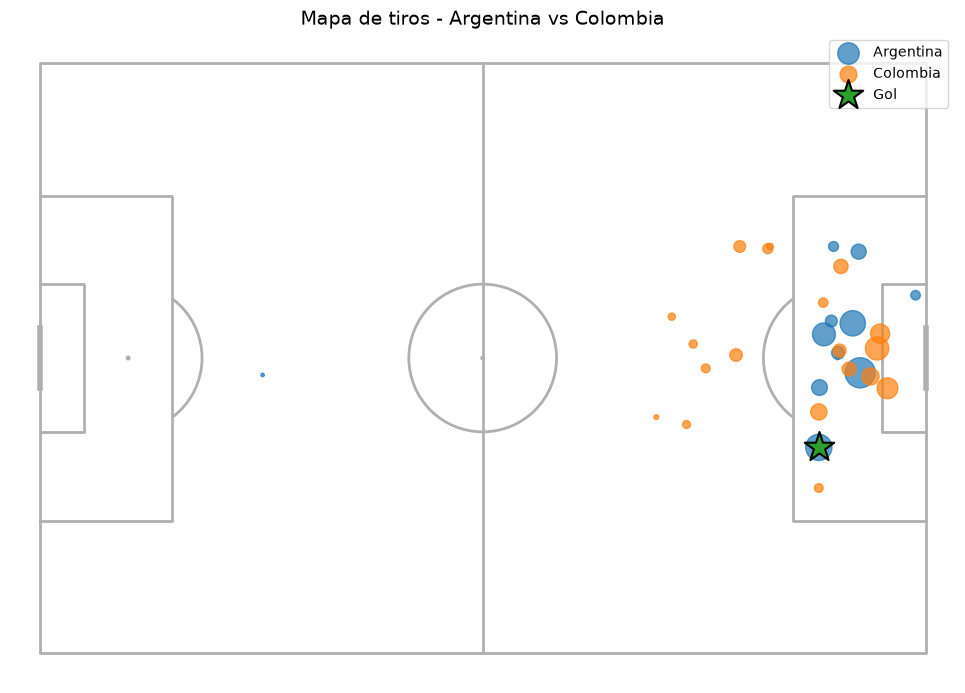

In [165]:
pitch = Pitch(
    pitch_type="statsbomb",
    axis=False,
    label=False
)

fig, ax = pitch.draw(figsize=(10, 7))

pitch.scatter(
    tiros_argentina["x"],
    tiros_argentina["y"],
    s=tiros_argentina["shot.statsbomb_xg"] * 1800,
    alpha=0.7,
    label="Argentina",
    ax=ax
)

pitch.scatter(
    tiros_colombia["x"],
    tiros_colombia["y"],
    s=tiros_colombia["shot.statsbomb_xg"] * 1800,
    alpha=0.7,
    label="Colombia",
    ax=ax
)

pitch.scatter(
    df_goles["x"],
    df_goles["y"],
    s=df_goles["shot.statsbomb_xg"] * 2500,
    marker="*",
    edgecolors="black",
    linewidth=1.5,
    label="Gol",
    ax=ax
)

ax.set_title(
    "Mapa de tiros - Argentina vs Colombia",
    fontsize=14
)

ax.legend()

plt.show()

## Pases y progresion

## Acciones defensivas y territorio